# Neural Networks

*Adapted from `pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html`.*

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor

# Excercise 1: Testing various activation functions.

The objective of this excercise is to investigate the impact of different activation functions on the performance of a two-hidden layer neural network using the FashionMNIST dataset.

In [2]:
# Define transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load training and validation datasets
trainset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True)

validationset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform)

validationloader = torch.utils.data.DataLoader(
    validationset, batch_size=64, shuffle=False)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:01<00:00, 6.23MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 252kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.03MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 5.64MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [3]:
# Define a general network class where activation function can be specified
class TwoHiddenLayerNN(nn.Module):
    def __init__(self, activation_function):
        super(TwoHiddenLayerNN, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.activation_function = activation_function
        
    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.activation_function(self.fc1(x))
        x = self.activation_function(self.fc2(x))
        x = self.fc3(x)
        return x

In [4]:
def train_model(activation_function, epochs=15):
    net = TwoHiddenLayerNN(activation_function)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(net.parameters(), lr=0.001)
    
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    
    for epoch in range(epochs):
        net.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for images, labels in trainloader:
            optimizer.zero_grad()
            outputs = net(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
        
        train_losses.append(running_loss / len(trainloader))
        train_accuracy = 100 * correct_train / total_train
        train_accuracies.append(train_accuracy)
        
        # Validation Phase
        net.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in validationloader:
                outputs = net(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
        
        val_losses.append(val_loss / len(validationloader))
        val_accuracy = 100 * correct_val / total_val
        val_accuracies.append(val_accuracy)
        
        print(f'Epoch {epoch+1}/{epochs}, '
              f'Train Loss: {train_losses[-1]:.4f}, '
              f'Validation Loss: {val_losses[-1]:.4f}, '
              f'Train Acc: {train_accuracy:.2f}%, '
              f'Validation Acc: {val_accuracy:.2f}%')
        
    return train_losses, val_losses, train_accuracies, val_accuracies

In [5]:
# Activation functions to test
activation_functions = {
    'ReLU': nn.ReLU(),
    'Sigmoid': nn.Sigmoid(),
    'Tanh': nn.Tanh()
}

results = {}

for name, activation_function in activation_functions.items():
    print(f'\nTraining with {name} activation function:')
    train_losses, val_losses, train_acc, val_acc = train_model(activation_function)
    results[name] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_acc': train_acc,
        'val_acc': val_acc
    }


Training with ReLU activation function:
Epoch 1/15, Train Loss: 0.3409, Validation Loss: 0.1678, Train Acc: 89.67%, Validation Acc: 94.68%
Epoch 2/15, Train Loss: 0.1551, Validation Loss: 0.1215, Train Acc: 95.31%, Validation Acc: 95.97%
Epoch 3/15, Train Loss: 0.1106, Validation Loss: 0.1064, Train Acc: 96.53%, Validation Acc: 96.64%
Epoch 4/15, Train Loss: 0.0930, Validation Loss: 0.1031, Train Acc: 97.09%, Validation Acc: 96.91%
Epoch 5/15, Train Loss: 0.0786, Validation Loss: 0.1175, Train Acc: 97.50%, Validation Acc: 96.17%
Epoch 6/15, Train Loss: 0.0675, Validation Loss: 0.0982, Train Acc: 97.83%, Validation Acc: 96.96%
Epoch 7/15, Train Loss: 0.0601, Validation Loss: 0.0949, Train Acc: 98.06%, Validation Acc: 97.03%
Epoch 8/15, Train Loss: 0.0541, Validation Loss: 0.0778, Train Acc: 98.23%, Validation Acc: 97.76%
Epoch 9/15, Train Loss: 0.0477, Validation Loss: 0.0760, Train Acc: 98.49%, Validation Acc: 97.70%
Epoch 10/15, Train Loss: 0.0445, Validation Loss: 0.1270, Train Acc:

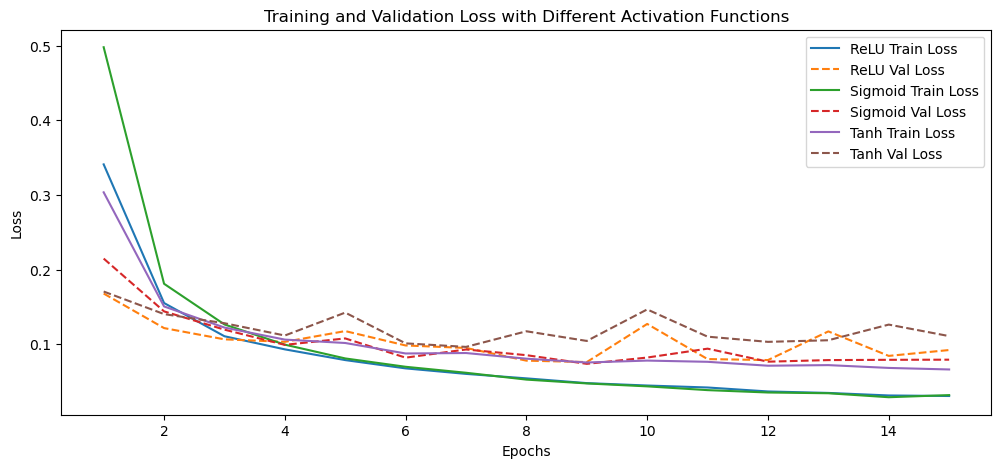

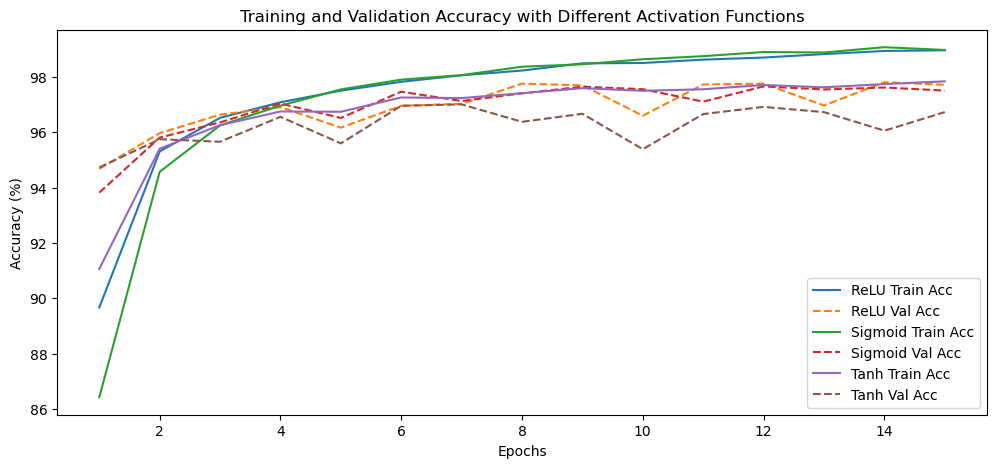

In [7]:
epochs_range = range(1, 16)

# Plot Losses
plt.figure(figsize=(12, 5))
for name in activation_functions.keys():
    plt.plot(epochs_range, results[name]['train_losses'], label=f'{name} Train Loss')
    plt.plot(epochs_range, results[name]['val_losses'], linestyle='--', label=f'{name} Val Loss')

plt.title('Training and Validation Loss with Different Activation Functions')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot Accuracies
plt.figure(figsize=(12, 5))
for name in activation_functions.keys():
    plt.plot(epochs_range, results[name]['train_acc'], label=f'{name} Train Acc')
    plt.plot(epochs_range, results[name]['val_acc'], linestyle='--', label=f'{name} Val Acc')

plt.title('Training and Validation Accuracy with Different Activation Functions')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

# Excercise 2: Fit a sine function with a 2-hidden layers NN

Objective: Use a two-hidden layer neural network to approximate a sine function. Visualize the network's predictions compared to the actual function.

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Generate data
x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)
y = np.sin(x)

# Convert to tensors
x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

In [9]:
class SineApproximator(nn.Module):
    def __init__(self):
        super(SineApproximator, self).__init__()
        self.fc1 = nn.Linear(1, 50)
        self.fc2 = nn.Linear(50, 50)
        self.fc3 = nn.Linear(50, 1)
        self.tanh = nn.Tanh()
        
    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        x = self.fc3(x)
        return x

net = SineApproximator()


In [10]:
criterion = nn.MSELoss()
optimizer = optim.Adam(net.parameters(), lr=0.01)

In [11]:
epochs = 1000
losses = []

for epoch in range(epochs):
    net.train()
    optimizer.zero_grad()
    outputs = net(x_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}')

Epoch 100/1000, Loss: 0.053820
Epoch 200/1000, Loss: 0.005805
Epoch 300/1000, Loss: 0.000121
Epoch 400/1000, Loss: 0.000051
Epoch 500/1000, Loss: 0.002142
Epoch 600/1000, Loss: 0.000021
Epoch 700/1000, Loss: 0.000013
Epoch 800/1000, Loss: 0.000134
Epoch 900/1000, Loss: 0.000013
Epoch 1000/1000, Loss: 0.000009


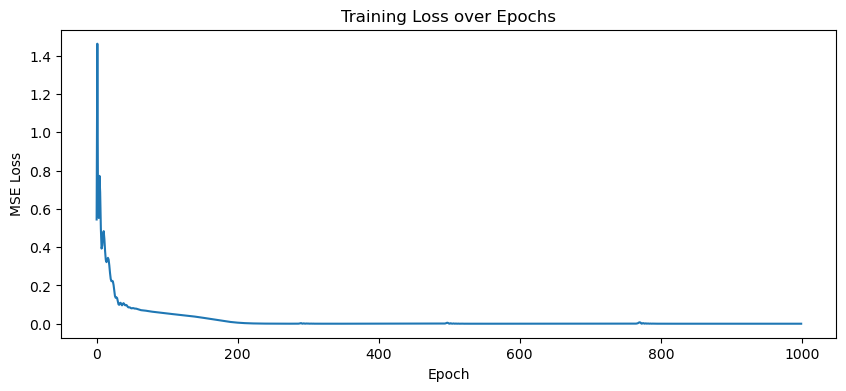

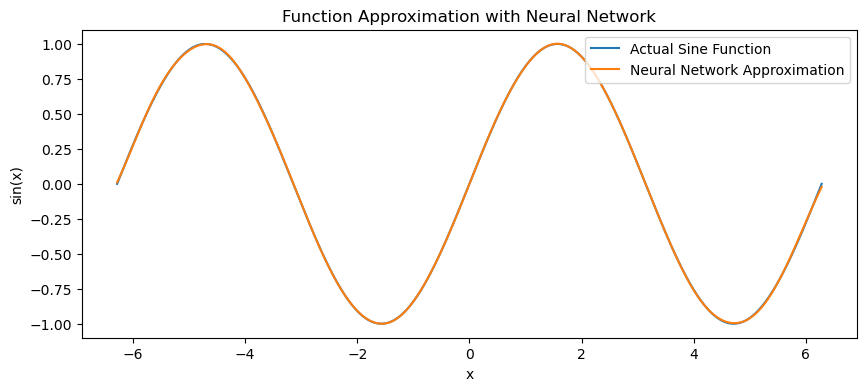

In [12]:
# Plot the training loss over epochs
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

# Plot the original sine function and the network's approximation
net.eval()
with torch.no_grad():
    predicted = net(x_tensor).numpy()

plt.figure(figsize=(10, 4))
plt.plot(x, y, label='Actual Sine Function')
plt.plot(x, predicted, label='Neural Network Approximation')
plt.legend()
plt.title('Function Approximation with Neural Network')
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.show()


# Exercise 3: Searching for Supersymmetric Collisions with Neural Nets

In [19]:
!curl -O https://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz

#If the former doesn't work, try this one below:
# !wget https://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  7294k      0 --:--:--  0:02:03 --:--:-- 12.0M  0     0  2212k      0 --:--:--  0:00:12 --:--:-- 2110k:00:22 --:--:-- 2523kk      0 --:--:--  0:00:48 --:--:-- 2657k:--:--  0:01:06 --:--:-- 11.4M 0  5197k      0 --:--:--  0:01:23 --:--:-- 11.1M76k      0 --:--:--  0:01:34 --:--:-- 11.0M6 --:--:-- 11.0M


In [20]:
!gunzip SUSY.csv.gz

#!gunzip "/content/SUSY.csv.gz" #use this one if you are using google colab colab

The SUSY dataset consists of 5 million simulated Monte Carlo samples
of supersymmetric and non-supersymmetric collisions. The goal is to distinguish between a process
where new supersymmetric particles are produced and a background process. The first 8 features are
measurements of the final particle states, while the last 10 features are functions of the first 8 derived
by physicists to help to discriminate the events.

In [13]:
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets

We provide the class `SUSY_Dataset` to load the train and test datasets.

In [21]:
class SUSY_Dataset(torch.utils.data.Dataset):
    """SUSY pytorch dataset."""

    def __init__(self, data_file, root_dir, dataset_size, train=True, transform=None, high_level_feats=None):
        """
        Args:
            data_file (string): Path to the csv file with annotations.
            root_dir (string): Directory with all the images.
            dataset_size (int): Size of the full dataset which is splitted in 80% for train and 20% for test.
            train (bool, optional): If set to `True` load training data.
            transform (callable, optional): Optional transform to be applied on a sample.
            high_level_festures (bool, optional): If set to `True`, working with high-level features only.
                                        If set to `False`, working with low-level features only.
                                        Default is `None`: working with all features
        """

        import pandas as pd

        features=['SUSY','lepton 1 pT', 'lepton 1 eta', 'lepton 1 phi', 'lepton 2 pT', 'lepton 2 eta', 'lepton 2 phi',
                'missing energy magnitude', 'missing energy phi', 'MET_rel', 'axial MET', 'M_R', 'M_TR_2', 'R', 'MT2',
                'S_R', 'M_Delta_R', 'dPhi_r_b', 'cos(theta_r1)']

        low_features=['lepton 1 pT', 'lepton 1 eta', 'lepton 1 phi', 'lepton 2 pT', 'lepton 2 eta', 'lepton 2 phi',
                'missing energy magnitude', 'missing energy phi']

        high_features=['MET_rel', 'axial MET', 'M_R', 'M_TR_2', 'R', 'MT2','S_R', 'M_Delta_R', 'dPhi_r_b', 'cos(theta_r1)']

        # Number of datapoints to work with
        df = pd.read_csv(root_dir+data_file, header=None,nrows=dataset_size,engine='python')
        df.columns=features
        Y = df['SUSY']
        X = df[[col for col in df.columns if col!="SUSY"]]

        # Set training and test data size
        train_size=int(0.8*dataset_size)
        self.train=train

        if self.train:
            X=X[:train_size]
            Y=Y[:train_size]
            print("Training on {} examples".format(train_size))
        else:
            X=X[train_size:]
            Y=Y[train_size:]
            print("Testing on {} examples".format(dataset_size-train_size))

        self.root_dir = root_dir
        self.transform = transform

        # make datasets using only the 8 low-level features and 10 high-level features
        if high_level_feats is None:
            self.data=(X.values.astype(np.float32),Y.values.astype(int))
            print("Using both high and low level features")
        elif high_level_feats is True:
            self.data=(X[high_features].values.astype(np.float32),Y.values.astype(int))
            print("Using both high-level features only.")
        elif high_level_feats is False:
            self.data=(X[low_features].values.astype(np.float32),Y.values.astype(int))
            print("Using both low-level features only.")

    # override __len__ and __getitem__ of the Dataset() class

    def __len__(self):
        return len(self.data[1])

    def __getitem__(self, idx):

        sample=(self.data[0][idx,...],self.data[1][idx])

        if self.transform:
            sample=self.transform(sample)

        return sample

In [22]:
training_data = SUSY_Dataset(
    data_file='SUSY.csv',
    root_dir='./',
    dataset_size=2000,
    train=True,
    )

test_data = SUSY_Dataset(
    data_file='SUSY.csv',
    root_dir='./',
    dataset_size=2000,
    train=False,
    )

Training on 1600 examples
Using both high and low level features
Testing on 400 examples
Using both high and low level features


1. To train our neural network with SGD, we want to pass the samples in batches. Build the train and
test data loaders, setting the batch size to 100 and activating reshuffling at each epoch for the train
data by setting `shuffle=True`.

In [23]:
batch_size = 100

train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

2. Define a fully connected ReLU neural network taking an 18-dimensional input, with two hidden layers with 200 neurons, one hidden layer with 100 neurons, and a final linear layer with two outputs.

In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = nn.Sequential(
    nn.Linear(18, 200),
    nn.ReLU(),
    nn.Linear(200, 200),
    nn.ReLU(),
    nn.Linear(200, 100),
    nn.ReLU(),
    nn.Linear(100, 2)
    ).to(device)

3. Using the cross-entropy loss and SGD with learning rate 1e-2, train the model for 100 epochs.

In [25]:
def train(dataloader, model, loss_fn, optimizer):
    '''
    This function implements the train loop. It iterates over the training dataset
    and try to converge to optimal parameters.
    '''
    size = len(dataloader.dataset)
    model.train() # Set the model to training mode
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction and loss
        pred = model(X) # Pass the data to the model to execute the model forward
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward() # Compute gradients of the loss w.r.t parameters (backward pass)
        optimizer.step() # Do a gradient descent step and adjust parameters
        optimizer.zero_grad() # Reset the gradients of model parameters to zero (gradients by default add up)

        if batch % 200 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


            

In [26]:
def test(dataloader, model, loss_fn):
    '''
    This function implements the validation/test loop. It iterates over the test
    dataset to check if the model performance is improving.
    '''
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval() # Set the model to evaluation mode
    test_loss, correct = 0, 0
    with torch.no_grad(): # Do not track gradients while evaluating (faster)
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item() # Compute CE loss on the batch
            correct += (pred.argmax(1) == y).type(torch.float).sum().item() # Compute classification error
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [27]:
loss_fn = nn.CrossEntropyLoss()

learning_rate = 1e-2
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 100
for t in range(epochs):
    print(f"Epoch {t+1}\n")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)

print("Done!")

Epoch 1

loss: 0.696220  [  100/ 1600]
Test Error: 
 Accuracy: 50.7%, Avg loss: 0.694212 

Epoch 2

loss: 0.693503  [  100/ 1600]
Test Error: 
 Accuracy: 58.0%, Avg loss: 0.692250 

Epoch 3

loss: 0.694435  [  100/ 1600]
Test Error: 
 Accuracy: 57.2%, Avg loss: 0.690390 

Epoch 4

loss: 0.694835  [  100/ 1600]
Test Error: 
 Accuracy: 58.5%, Avg loss: 0.688562 

Epoch 5

loss: 0.687079  [  100/ 1600]
Test Error: 
 Accuracy: 60.2%, Avg loss: 0.686770 

Epoch 6

loss: 0.686924  [  100/ 1600]
Test Error: 
 Accuracy: 60.5%, Avg loss: 0.685025 

Epoch 7

loss: 0.684555  [  100/ 1600]
Test Error: 
 Accuracy: 61.3%, Avg loss: 0.683290 

Epoch 8

loss: 0.687673  [  100/ 1600]
Test Error: 
 Accuracy: 61.8%, Avg loss: 0.681559 

Epoch 9

loss: 0.687730  [  100/ 1600]
Test Error: 
 Accuracy: 62.0%, Avg loss: 0.679818 

Epoch 10

loss: 0.686509  [  100/ 1600]
Test Error: 
 Accuracy: 62.3%, Avg loss: 0.678071 

Epoch 11

loss: 0.674508  [  100/ 1600]
Test Error: 
 Accuracy: 62.3%, Avg loss: 0.676280